In [ ]:
%load_ext autoreload
%autoreload 2
import torch
from utils import goto_project_root
from utils.path_settings import MODEL_SAVE_PATH, DATA_PATH, LOG_PATH, CONFIG_PATH, OBJECT_PATH
from torch.utils.tensorboard import SummaryWriter
import SimulateDatasets.GenTrainingData as g
from utils import create_splits, get_dataloaders, force_remove_dir
from Network_models import VaeTrainer as t
from importlib import reload
import os
reload(t)
reload(g)
import time
import numpy as np
from pytorch3d.transforms import so3_relative_angle
from pytorch3d.transforms import quaternion_to_matrix
import json
import Train_task.train_from_config_names as train
reload(train)
import torchvision.models as models

In [2]:
obj_path_dict = {
    "cow": OBJECT_PATH + "\\cow_mesh\\cow.obj",
    "A1": OBJECT_PATH + "\\stim_simple\\A1_5x6x5_centered.obj",
    "A2": OBJECT_PATH + "\\stim_simple\\A2_5x6x5_centered.obj",
    "B1": OBJECT_PATH + "\\stim_simple\\B1_6x6x6_centered.obj",
    "B2": OBJECT_PATH + "\\stim_simple\\B2_6x6x6_centered.obj",
    "C1": OBJECT_PATH + "\\stim_simple\\C1_5x6x5_centered.obj",
    "C2": OBJECT_PATH + "\\stim_simple\\C2_5x6x5_centered.obj",
    "D1": OBJECT_PATH + "\\stim_simple\\D1_5x6x5_centered.obj",
    "D2": OBJECT_PATH + "\\stim_simple\\D2_5x6x5_centered.obj",
    "E1": OBJECT_PATH + "\\stim_simple\\E1_5x5x6_centered.obj",
    "E2": OBJECT_PATH + "\\stim_simple\\E2_5x5x6_centered.obj",
}
obj_index_dict = {
    "cow": None, 
    "A1": "5x6x5_centered",
    # "A2": "5x6x5_centered",
    # "B1": "6x6x6_centered",
    # "B2": "6x6x6_centered",
    # "C1": "5x6x5_centered",
    # "C2": "5x6x5_centered",
    # "D1": "5x6x5_centered",
    # "D2": "5x6x5_centered",
    # "E1": "5x5x6_centered",
    # "E2": "5x5x6_centered",
}
cam_position = {
    "cow": 3,
    "A1": 8,
    "A2": 8,
    "B1": 8,
    "B2": 8,
    "C1": 8,
    "C2": 8,
    "D1": 8,
    "D2": 8,
    "E1": 8,
    "E2": 8,
}

In [4]:
obj_path_dict.get("cow", None)

'C:\\Users\\timmy\\Documents\\Projects_dir\\Mental_Rotations\\mental-rotations\\data\\cow_mesh\\cow.obj'

In [190]:
obj_name = "cow"
obj_index = obj_index_dict.get(obj_name, None)
obj_path = obj_path_dict.get(obj_name, None)
cam_pos = cam_position.get(obj_name, None)
obj_name = obj_name + "_" + obj_index + ".obj" if obj_index is not None else obj_name + ".obj"

network_name = "simple_VAE_constant_alt"
task_name = "1.1"
re_train = 0
resolution_in = 64
resolution_out = resolution_in
latent_dimension = 32

config = {"model_specs": {
    "model_name": "RotationVAE",  # to be added (CustomRNN or FC_RNN)
    "model_path": "Network_models.RotationVAE",
    "model_params": {
        "input_resolution": resolution_in,
        "output_resolution": resolution_out,
        "latent_dimension": latent_dimension,
        "encoder": "simple", 
        "decoder": "FC",
        }, 
}, "model_id": network_name, "device": "cuda", "scheduler": True, # Uses the ReduceLROnPlateau scheduler
    "optimizer_specs": {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.01
    }
}, "reconstruction_loss": "MSE", "kl_divergence_loss": "Normal", "annealing": True, "annealing_function": "constant",
    "training_config": {
        "task_id": "1.1",
        "batch_size": 1024,
        "mini_batch_size":256,
        "resolution": resolution_in,
        "cam_position": 2.1,#cam_pos,
        "object_path": obj_path,
        "use_AR": True, 
    }, 'save_path': MODEL_SAVE_PATH + f"\\{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out"
                                        f"{resolution_out}_model", 
    'log_path': LOG_PATH + f"\\{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out{resolution_out}",
    'check_path': MODEL_SAVE_PATH + f"\\{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out"
                                        f"{resolution_out}_model_checkpoints",
}
config['training_config']['data_save_path'] = (DATA_PATH + 
                                               f"\\Data_{task_name}_res{config['training_config']['resolution']}_{obj_name[:-4]}_cam{config['training_config']['cam_position']}"
                                               f".pth")

for path in [config['save_path'], config['log_path'], config['check_path']]:
    if not os.path.exists(path):
        os.makedirs(path)
    elif not re_train:
        print(f"Path already exists for {network_name} in task {task_name}. Assume the model is already trained.")
    else: # re_train
        force_remove_dir(path)
        os.makedirs(path)
print(config['save_path'])
json.dump(config, open(CONFIG_PATH + f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}_configs"
                                     f".json", "w"))

D:\Projects\mental-rotations\models\simple_VAE_constant_alt_latent32_res_in64_res_out64_model


In [192]:
experimental_trainer = t.VaeTrainer(config)
experimental_trainer.model.resolution_in = config['training_config']['resolution'] 
data_path = config['training_config']['data_save_path'][:-4] if config['training_config']['data_save_path'][-4:] == ".pth"\
    else config['training_config']['data_save_path']
if os.path.exists(data_path + "_train.pth"):
    data= torch.load(data_path + "_train.pth")
else: 
    d = g.gen_training_data(config['training_config'])
    data = torch.load(data_path + "_train.pth")
dataloaders = get_dataloaders(data, batch_size = config['training_config']['mini_batch_size'], k = 5)
epochs = 1000
print(f"Training {network_name} on task {task_name}, saving to {config['save_path']}; copy the below for logs")
print(f"tensorboard --logdir={config['log_path']}")
for i in range(len(dataloaders)):
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    force_remove_dir(sub_log_path) # Probably redundant but helps to ensure no old logs are kept
    os.makedirs(sub_log_path, exist_ok = True)
    os.makedirs(sub_check_path, exist_ok = True)

# keep a record on the best split: 
best_split_val_loss = torch.tensor(float('inf'))
for i, (train_loader, val_loader) in enumerate(dataloaders):
    print(f"Training split {i + 1}")
    experimental_trainer.refresh()
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    experimental_trainer.train(train_loader,
                      val_loader,
                      epochs=epochs,
                      save_path = config["save_path"] + f"\\model_{i+1}.pth",
                      check_path= sub_check_path,
                      log_path = sub_log_path, early_stopping = True)
    if experimental_trainer.best_val_loss < best_split_val_loss:
        best_split_val_loss = experimental_trainer.best_val_loss
        best_split = i + 1

    experimental_trainer.save_model(config["save_path"] + f"\\model_{i+1}.pth", full=1)
experimental_trainer.load_best_model()
print(f"Training {network_name} on task {task_name} complete. Saving best model to {config['save_path']}.")
experimental_trainer.save_model(config["save_path"] + f"\\best_model.pth", full=1)

trying to initialise VAE
Using a scheduler
Training simple_VAE_constant_alt on task 1.1, saving to D:\Projects\mental-rotations\models\simple_VAE_constant_alt_latent32_res_in64_res_out64_model; copy the below for logs
tensorboard --logdir=D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64
Successfully removed directory: D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64\split_1
Successfully removed directory: D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64\split_2
Successfully removed directory: D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64\split_3
Successfully removed directory: D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64\split_4
Successfully removed directory: D:\Projects\mental-rotations\logs\simple_VAE_constant_alt_latent32_res_in64_res_out64\split_5
Training split 1
Early stopping
Training spli

In [21]:
data_test = torch.load(data_path + "_test.pth")

In [194]:
# See how the model performs on this image.
import matplotlib.pyplot as plt
def reinitialise_weights(model):
    for layer in model.children():
        if not hasattr(layer, 'frozen') or not layer.frozen:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()
            elif isinstance(layer, nn.Sequential) or isinstance(layer, nn.ModuleList) or isinstance(layer, nn.Module):
                reinitialise_weights(layer)

experimental_trainer.model.eval()
# experimental_trainer.load_model(config["save_path"] + f"\\model_1.pth", full=1)
split = 3
cp = 499
experimental_trainer.load_checkpoint(config['check_path'] + f'\\split_{split}\\checkpoint{cp}.pth')
# reinitialise_weights(experimental_trainer.model)
x_hat, mean, log_var= experimental_trainer.model(data_test.data.cuda())
print(f"Mean: {mean}")
print(f"Log variance: {log_var}")

Mean: tensor([[-1.4956,  0.7310, -3.6351,  ..., -3.9354, -1.8559,  2.5062],
        [-3.4284,  1.5984, -4.0148,  ..., -0.9532, -1.1601,  1.3622],
        [-2.4353,  1.1600, -0.8779,  ...,  1.1270,  4.4000,  3.0542],
        ...,
        [-0.3411,  2.0410, -3.3389,  ..., -0.5342,  2.5354,  3.1004],
        [-4.6632, -2.2511, -2.4929,  ...,  1.5224,  3.0066,  4.7721],
        [-2.3096,  2.5729, -1.8645,  ..., -1.2883, -1.4940, -0.4282]],
       device='cuda:0', grad_fn=<AddmmBackward0>)
Log variance: tensor([[ -6.5857,  -8.9956,  -9.5467,  ..., -10.3630,  -8.3401,  -9.1116],
        [ -5.3272,  -7.5686,  -7.2536,  ...,  -9.1643,  -7.0383,  -8.5803],
        [ -9.9650, -10.0425, -12.1224,  ..., -10.4589,  -9.4272, -10.2023],
        ...,
        [-10.3233, -12.4644, -13.5771,  ..., -13.2960, -10.4244, -12.9446],
        [ -6.7814,  -9.0213, -10.0839,  ..., -10.8420,  -8.4459,  -9.2039],
        [ -6.8145,  -8.4279,  -8.7684,  ...,  -9.4924,  -8.9839,  -9.9136]],
       device='cuda:0', gr

In [148]:
layers = []
for i in experimental_trainer.model.decoder.graph.children():
    layers.append(i)

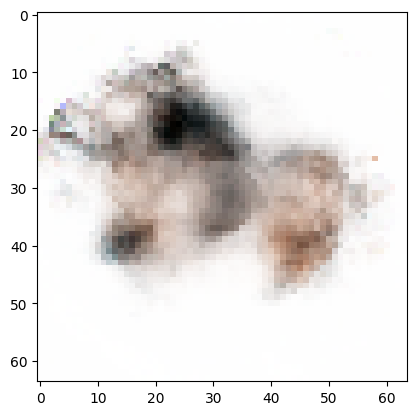

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14175035..1.3910736].


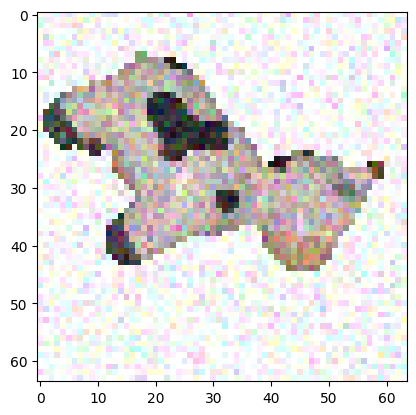

In [199]:
data_index = 100
pred = x_hat[data_index, ...].detach().cpu().numpy().transpose(1,2,0)

pred = (pred - np.min(pred)) / (np.max(pred) - np.min(pred))
plt.imshow(pred)
plt.show()
noise = torch.randn_like(data_test.data[data_index, ...]) * 0.1
plt.imshow((noise + data_test.data[data_index, ...]).detach().cpu().numpy().transpose(1,2,0))
plt.show()

tensor([[-0.9897,  0.8435, -1.6264, -0.5696,  1.3508,  0.7554,  1.4449,  1.3745,
         -1.7349, -1.8704, -0.1686, -0.5330, -0.6433, -0.2826, -0.0474,  0.4642,
          0.8754, -1.7562, -1.1822, -1.3035, -0.1246, -0.6946,  0.0968,  1.0122,
          0.9474,  1.0125, -1.9481,  0.2345,  0.0419, -0.4561, -1.6976, -0.6519]],
       device='cuda:0')


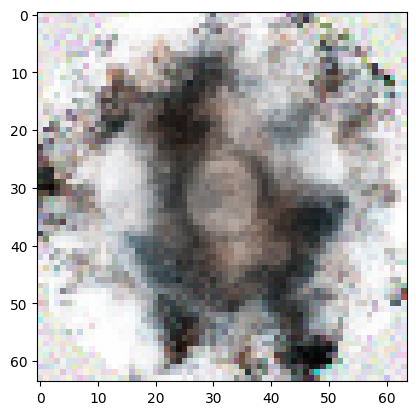

In [163]:
z_sample = torch.randn(1, 32).cuda()
print(z_sample)
x_hat = experimental_trainer.model.decoder(z_sample)
plt.imshow(1 - x_hat[0, ...].detach().cpu().numpy().transpose(1,2,0))

In [155]:
continue_training_path = data_path + "_train2.pth"
task = "1.1"
regenerate = False
network_best_split = {
    "ConvNeXt_Tiny": best_split,
}
for network_name, split in network_best_split.items():
    epochs = 200
    trainer = t.Trainer(config)
    trainer.load_checkpoint(config['check_path'] + f"\\split_{split}\\checkpoint29.pth")
    # trainer.scheduler = None
    if (not os.path.exists(continue_training_path)) or regenerate:
        print('Generating data')
        data = g.gen_training_data(config['training_config'])
    else: 
        data = torch.load(continue_training_path)
    import utils as u
    reload(u)
    dataloaders = u.get_dataloaders(data, config['training_config']['mini_batch_size'], 1)
    print("Continue training the best model")
    sub_log_path = config['log_path'] + "\\continue_training"
    sub_check_path = config['check_path'] + "\\continue_training"
    force_remove_dir(sub_log_path)
    force_remove_dir(sub_check_path)
    os.makedirs(sub_log_path, exist_ok=True)
    os.makedirs(sub_check_path, exist_ok=True)
    trainer.train(
        dataloaders[0][0],
        dataloaders[0][1],
        epochs=epochs,
        save_path = config['save_path'] + "\\continue_training.pth",
        check_path=sub_check_path,
        log_path = sub_log_path,
    )
    trainer.save_model(config['save_path'] + "\\continue_training.pth", full = 1)
    trainer.load_best_model()
    trainer.save_model(config['save_path'] + "\\best_model.pth", full = 1)

AttributeError: module 'Network_models.VaeTrainer' has no attribute 'Trainer'

In [44]:
# Generate training data for all these training images
reload(g)
training_config = config['training_config']

for stim_name, stim_dimension in obj_index_dict.items():
    stim = f"{stim_name}_{stim_dimension}" if stim_dimension is not None else stim_name
    training_config['object_path'] = obj_path_dict[stim_name]
    training_config['data_save_path'] = (DATA_PATH + f"\\Data_{task_name}_res{training_config['resolution']}_{stim}.pth")
        
    if not os.path.exists(training_config['data_save_path']):
        print('Generating data')
        data = g.gen_training_data(training_config)
# dataloaders = get_dataloaders(data, batch_size = training_config['mini_batch_size'], k = 5)


Layer 0 is frozen: True
Layer 0 is Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (1): Sequential(
    (0): CNBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=96, out_features=384, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=384, out_features=96, bias=True)
        (6): Permute()
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): CNBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=96, out_features=384, bias=True)
  

In [ ]:
for i, layer in enumerate(experimental_trainer.model.children()):
    if hasattr(layer, "frozen"): 
        print(f"Layer {i} is frozen: {layer.frozen}")
    print(f"Layer {i} is {layer}")
experimental_trainer.refresh()

# Try PCA

In [200]:
def PCA_torch(data):
    data = data - torch.mean(data, dim=0)
    U, S, V = torch.svd(data)
    return U, S, V


In [229]:
images = data.data[:500, 0, ...].flatten(1)
U, S, V = PCA_torch(images)

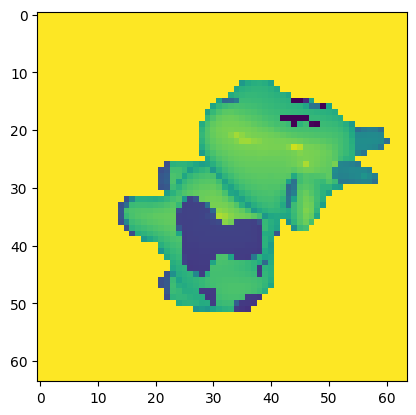

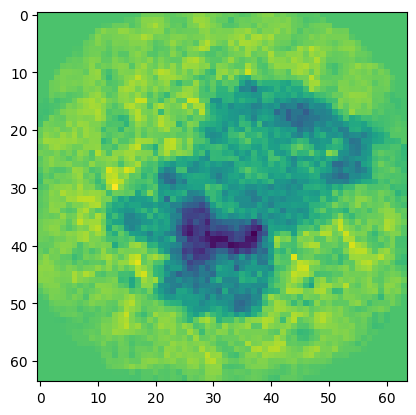

In [235]:
new_image = data.data[1000, 0, ...].flatten(0).unsqueeze(0)
means = torch.mean(new_image, dim=1)
new_image = new_image - means
dim = 256
compressed = torch.mm(new_image, V[:, :dim])
reconstructed = torch.mm(compressed, V[:, :dim].t()) + means
plt.imshow(new_image[0].unflatten(0, (64, 64)).cpu().numpy())
plt.show()
plt.imshow(reconstructed[0].unflatten(0, (64, 64)).cpu().numpy())
plt.show()

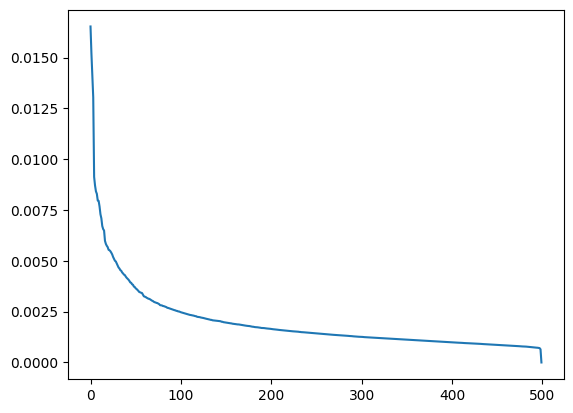

In [104]:
# plot the components' variation explained
va = S / torch.sum(S)
plt.plot(va.cpu().numpy())